# CAB320 Assignment 2 - Transfer Learning
Anthony Vanderkop, Thierry Peynot, Frederic Maire (Jupyter Notebook template: 2025)


## Instructions:
The functions and classes defined in this module will be called by the marker without modification. 
You should complete the functions and classes according to their specified interfaces.

No partial marks will be awarded for functions that do not meet the specifications of the interfaces.


In [1]:
### LIBRARY IMPORTS ###
import os
import numpy as np

import keras.applications as ka
import keras
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.model_selection import train_test_split
import tensorflow as tf

## Task 1
Implement the my_team()function 

In [2]:
def my_team():
    '''
    Return the list of the team members of this assignment submission as a list
    of triplet of the form (student_number, first_name, last_name)
    
    '''
    return [('n0827053', 'Ashley', 'Longhurst'), ('Kyle', 'Ruter')] 

In [3]:
my_team()

[('n0827053', 'Ashley', 'Longhurst'), ('Kyle', 'Ruter')]

## Task 2
Download the small_flower_dataset from Canvas and load the data

In [4]:
def load_data(path):
    '''
    Load in the dataset from its home path. Path should be a string of the path
    to the home directory the dataset is found in. Should return a numpy array
    with paired images and class labels.
    
    Insert a more detailed description here.
    '''
    subfolders = ['daisy', 'dandelion', 'roses', 'tulips', 'sunflowers']
    
    images = []
    labels = []
    
    label_map = {
        'daisy': 0,
        'dandelion': 1,
        'roses': 2,
        'tulips': 3,
        'sunflowers': 4
    }
    
    for subfolder in subfolders:
        full_path = os.path.join(path, subfolder)   # uses the argument now
        image_files = os.listdir(full_path)
    
        for img_file in image_files:
            img_path = os.path.join(full_path, img_file)
            img = cv2.imread(img_path)
    
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (128, 128))
                images.append(img)
                labels.append(label_map[subfolder])
    
    X = np.array(images)
    y = np.array(labels)
    
    print("All images shape:", X.shape)
    print("All labels shape:", y.shape)
    print("Class labels:", label_map)
    dataset = np.array(list(zip(X, y)), dtype=object)
    return dataset
   

In [6]:
dataset = load_data('./small_flower_dataset')
X = np.array([item[0] for item in dataset])
Y = np.array([item[1] for item in dataset])

All images shape: (1000, 128, 128, 3)
All labels shape: (1000,)
Class labels: {'daisy': 0, 'dandelion': 1, 'roses': 2, 'tulips': 3, 'sunflowers': 4}


In [7]:
"""
We want to have a look at how the images are set up
"""

print(X[0][0]) # The first row of pixels just to look at the values 0 - 255. Each pixel RGB values
print(len(X[0][0])) # 128 - First row has 128. So all looks ok. 
                    # Will we need to resize or normalise for the CNN part?

[[ 26  39  17]
 [ 61  64  79]
 [239 242 248]
 [238 245 251]
 [238 245 253]
 [235 244 253]
 [229 241 250]
 [220 232 246]
 [208 224 246]
 [186 208 234]
 [167 196 228]
 [154 186 226]
 [147 182 224]
 [146 180 225]
 [149 182 225]
 [145 180 226]
 [142 177 225]
 [138 174 211]
 [103 139 156]
 [ 30  65  82]
 [ 79 117 179]
 [130 173 224]
 [127 172 224]
 [128 171 224]
 [128 171 224]
 [127 171 223]
 [130 171 223]
 [130 171 225]
 [129 169 223]
 [129 170 223]
 [129 170 226]
 [129 170 223]
 [128 171 224]
 [128 171 224]
 [129 172 225]
 [131 172 226]
 [130 171 225]
 [131 172 226]
 [131 171 226]
 [131 172 226]
 [132 173 227]
 [132 173 226]
 [133 174 226]
 [132 173 225]
 [132 173 225]
 [132 173 226]
 [133 174 227]
 [133 174 227]
 [134 174 226]
 [135 175 227]
 [135 175 227]
 [140 176 227]
 [138 176 227]
 [137 177 229]
 [139 178 229]
 [140 178 230]
 [141 179 230]
 [140 178 230]
 [142 179 232]
 [140 180 232]
 [137 178 230]
 [140 180 231]
 [140 180 231]
 [140 180 231]
 [138 180 230]
 [139 181 231]
 [139 181 

In [9]:
"""
A quick check to see how the data is structured and to see if
class labels a fairly balanced. This code block wont be imcluded in the final submission.
"""
print(np.unique(Y, return_counts=True)) # We can see there are 200 of each

(array([0, 1, 2, 3, 4]), array([200, 200, 200, 200, 200]))


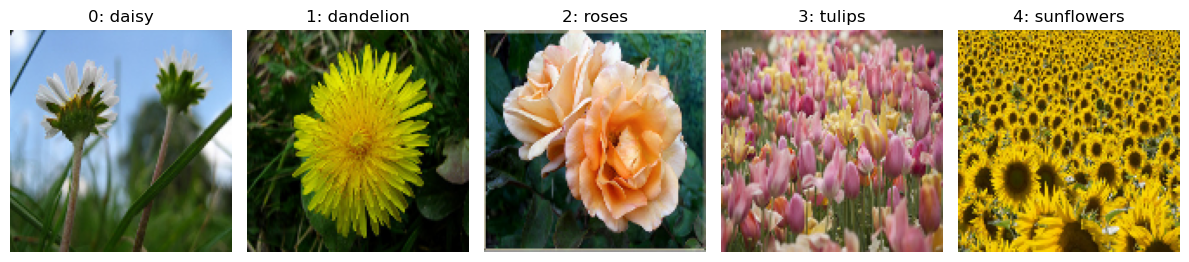

In [10]:
"""
This code block is just to see the load has worked
and to see if the labels and the images are matched.
It probably wont be included in the final submission
"""

label_map_check = {
    0: 'daisy',
    1: 'dandelion',
    2: 'roses',
    3: 'tulips',
    4: 'sunflowers'
}

plt.figure(figsize=(12, 4))

for flower_label in range(5):
    for i in range(len(dataset)):
        image = dataset[i][0]
        label = dataset[i][1]

        if label == flower_label:
            plt.subplot(1, 5, flower_label + 1)
            plt.imshow(image)
            plt.title(f"{label}: {label_map_check[label]}")
            plt.axis('off')
            break

plt.tight_layout()
plt.show()

## Task 3
Prepare your training, validation and test sets for the non-accelerated version of transfer learning.

In [11]:
def split_data(X, Y, train_fraction, randomize=False, eval_set=True):
    """
    Split the data into training and testing sets. If eval_set is True, also create
    an evaluation dataset. There should be two outputs if eval_set there should
    be three outputs (train, test, eval), otherwise two outputs (train, test).
    
    To see what type train, test, and eval should be, refer to the inputs of 
    transfer_learning().
    
    This uses sklearn's train test split library. See https://scikit-learn.org/stable/modules/generated/
    sklearn.model_selection.train_test_split.html. The output type conforms to the transfer_learning()
    input data type (a tuple of images and labels : eg (images, labesl)). Random state is utilised for reproducability
    initially among team members and the randomise is used to ensure no class imbalance.
    """
    if eval_set:
        # First split: training set and leftover set
        X_train, X_temp, Y_train, Y_temp = train_test_split(
            X,
            Y,
            train_size=train_fraction,
            shuffle=randomize,
            random_state=42
        )

        # Second split: split leftover data equally into test and eval sets
        X_test, X_eval, Y_test, Y_eval = train_test_split(
            X_temp,
            Y_temp,
            test_size=0.5,
            shuffle=randomize,
            random_state=42
        )

        train = (X_train, Y_train)
        test = (X_test, Y_test)
        eval_data = (X_eval, Y_eval)

        return train, test, eval_data

    else:
        X_train, X_test, Y_train, Y_test = train_test_split(
            X,
            Y,
            train_size=train_fraction,
            shuffle=randomize,
            random_state=42
        )

        train = (X_train, Y_train)
        test = (X_test, Y_test)

        return train, test

In [12]:
def get_sets(X, Y, train_ratio=0.8, randomize=True, use_eval=True):
    '''
    Split data into train/test sets, with an optional evaluation set.
    '''
    if use_eval:
        train_set, test_set, eval_set = split_data(
            X, Y, train_ratio, randomize=randomize, eval_set=True
        )
    else:
        train_set, test_set = split_data(
            X, Y, train_ratio, randomize=randomize, eval_set=False
        )
        eval_set = None
    return train_set, test_set, eval_set

In [13]:
train_set, test_set, eval_set = get_sets(X, Y, train_ratio=0.8, randomize=True, use_eval=True)

In [14]:
"""
Plots to show how the train test split function worked 
and if any class imbalance exists in the sets. This can be talked
about in the text block below latwer on. 
"""
def plot_class_distributions(train_set, test_set, eval_set=None, label_map=None):
 
    sets = [('Training Set', train_set[1]), ('Testing Set', test_set[1])]
    if eval_set is not None:
        sets.append(('Evaluation Set', eval_set[1]))

    n = len(sets)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))

    if n == 1:
        axes = [axes]

    for ax, (title, y) in zip(axes, sets):
        unique, counts = np.unique(y, return_counts=True)
        names = [label_map[i] for i in unique] if label_map else unique
        ax.bar(names, counts)
        ax.set_title(f'{title} (n={len(y)})')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

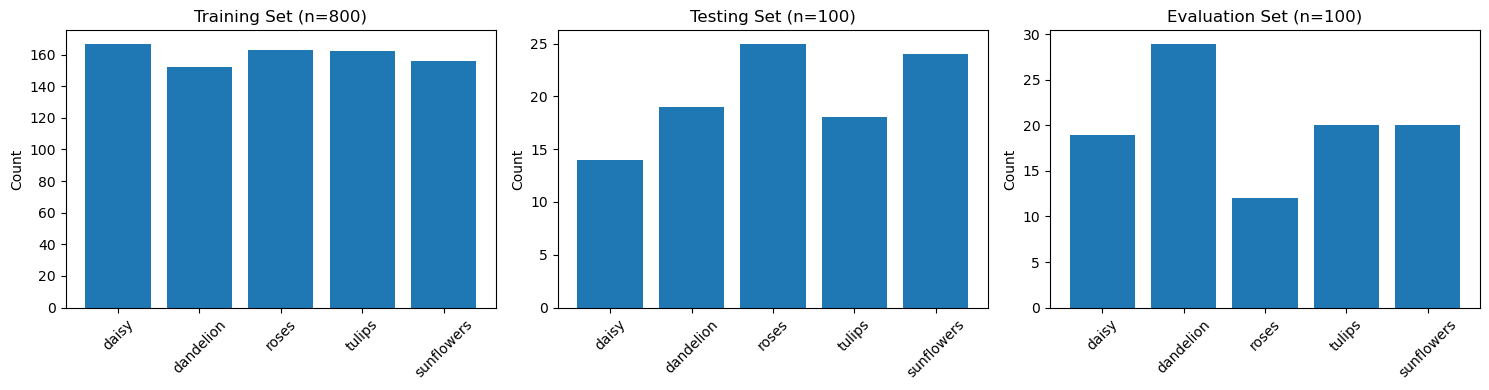

In [15]:
plot_class_distributions(train_set, test_set, eval_set, label_map=label_map_check)

Report: Include details of how you have split the data to perform this training. Ensure the split is reasonable and does not introduce class imbalance during training

Insert details here.


## Task 4
Using the tf.keras.applications module download a pretrained MobileNetV2 network. 

In [16]:
def load_model():
    '''
    Load in a model using the tf.keras.applications model and return it.
    Insert a more detailed description here
    '''
    model = tf.keras.applications.MobileNetV2(
    weights='imagenet'
    )

    return model    

In [17]:
model = load_model()
model.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,538,984 (13.50 MB)

 Trainable params: 3,504,872 (13.37 MB)

 Non-trainable params: 34,112 (133.25 KB)

(224, 224, 3)


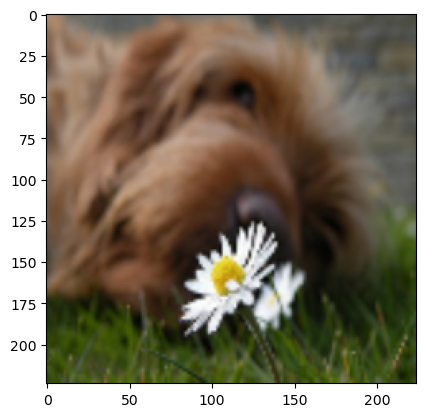

In [18]:
"""
Having a look at the pretrained model, we can see that the input layer is 224x224x3.
Our images are 128x128x3. As the model is pretrained on 224 images we shouldn't change the weights in the
actual model. We need to resize our own images to conform to the input size of the pretrained model. Also, have to
try and find what sort of data the MobileNetV2 was trained on. eg was it (0-255) or something different.
It was (-1 : +1). Quote from Keras page " Note: each TF-Keras Application expects a specific 
kind of input preprocessing. For MobileNet, call tf.keras.applications.mobilenet.preprocess_input on 
your inputs before passing them to the model. mobilenet.preprocess_input will scale input pixels between -1 and 1."
"""

# Resize all sets of images (Train, Test, Val)

resized_train = tf.image.resize(train_set[0], [224, 224])
resized_test = tf.image.resize(test_set[0], [224, 224])
resized_val = tf.image.resize(eval_set[0], [224, 224])

# Check to see if it worked
print(resized_train[0].shape)

# What does it look like
plt.imshow(resized_train[0] / 255.0)

# Rescale images
final_train_imgs = tf.keras.applications.mobilenet_v2.preprocess_input(resized_train)
final_test_imgs = tf.keras.applications.mobilenet_v2.preprocess_input(resized_test)
final_val_imgs = tf.keras.applications.mobilenet_v2.preprocess_input(resized_val)

# Add the labels back
final_train = (final_train_imgs, train_set[1])
final_test  = (final_test_imgs,  test_set[1])
final_val   = (final_val_imgs,   eval_set[1])

In [19]:
"""
This is for Task 5
"""
# Get the output of the previous layer (Global Average Pooling)
previous_layer_output = model.layers[-2].output

# Add required final layer
new_final_layer = tf.keras.layers.Dense(5, activation='softmax')(previous_layer_output)

# Create the new mmodel
new_model = tf.keras.Model(inputs=model.input, outputs=new_final_layer)

# Freeze training on the original layers
for layer in new_model.layers[:-1]:
    layer.trainable = False

new_model.summary()

# From the last line of the summary we can see that only the last layer is trainable (6405).

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Task 5
Replace the last layer of the downloaded neural network with a Dense layer of the appropriate shape for the 5 classes of the small flower dataset {(x1,t1), (x2,t2),..., (xm,tm)}.

## Task 6
Compile and train your model with an SGD optimizer using the following parameters learning_rate=0.01, momentum=0.0, nesterov=False. (NB: The SGD class description can be found at https://keras.io/api/optimizers/sgd/  )

In [20]:
def transfer_learning(train_set, eval_set, model, parameters):
    '''
    Implement and perform standard transfer learning here.

    Inputs:
        - train_set: list or tuple of the training images and labels in the
            form (images, labels) for training the classifier
        - eval_set: list or tuple of the images and labels used in evaluating
            the model during training, in the form (images, labels)
        - model: an instance of tf.keras.applications.MobileNetV2
        - parameters: list or tuple of parameters to use during training:
            (learning_rate, momentum, nesterov)


    Outputs:
        - model : an instance of tf.keras.applications.MobileNetV2

    '''
    # Unpack the images and labels
    train_images, train_labels = final_train
    eval_images, eval_labels = final_val
    learning_rate, momentum, nesterov = parameters

    # Set up the optimiser
    optimizer = tf.keras.optimizers.SGD(
        learning_rate=learning_rate,
        momentum=momentum,
        nesterov=nesterov
    )

    # Compile the model
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train the model
    history = model.fit(
        train_images,
        train_labels,
        validation_data=(eval_images, eval_labels),
        epochs=30,
        batch_size=32,
        verbose=1
    )

    return model, history

In [21]:
# model = transfer_learning()
parameters = (0.001, 0.9, True)

model, history = transfer_learning(final_train, final_val, new_model, parameters)

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 177ms/step - accuracy: 0.3375 - loss: 1.5758 - val_accuracy: 0.5200 - val_loss: 1.1417
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 162ms/step - accuracy: 0.7038 - loss: 0.8756 - val_accuracy: 0.6900 - val_loss: 0.7911
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 162ms/step - accuracy: 0.7850 - loss: 0.6570 - val_accuracy: 0.7500 - val_loss: 0.6777
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 164ms/step - accuracy: 0.8225 - loss: 0.5550 - val_accuracy: 0.7900 - val_loss: 0.6211
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 165ms/step - accuracy: 0.8462 - loss: 0.4904 - val_accuracy: 0.8200 - val_loss: 0.5679
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 164ms/step - accuracy: 0.8637 - loss: 0.4469 - val_accuracy: 0.8100 - val_loss: 0.5483
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 163ms/step - accuracy: 0.8775 - loss: 0.4108 - val_accuracy: 0.8300 - val_loss: 0.5176
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 164ms/step - accuracy: 0.8900 - loss: 0.3846 - val_accuracy: 0.

## Task 7
Plot the training and validation errors and accuracies of standard transfer 

In [19]:
## Your Code


## Task 8
Experiment with 3 different orders of magnitude for the learning rate. Plot the results and discuss in the below markdown cell

In [20]:
## Your code

### Task 8 Analysis and discussion


## Task 9
Run the resulting classifier on your test dataset using results from the best learning rate you experimented with. Compute and display the confusion matrix. 

In [21]:
## Your code

## Task 10
Compute the precision, recall, and f1 scores of your classifier on the test dataset using the best learning rate. Report on the results and comment. 

In [23]:
## Your code

## Task 11
Perform k-fold validation on the dataset with k = 3. 

In [36]:
def k_fold_validation(features, ground_truth, classifier, k=2):
    '''
    Inputs:
        - features: np.ndarray of features in the dataset
        - ground_truth: np.ndarray of class values associated with the features
        - fit_func: f
        - classifier: class object with both fit() and predict() methods which
        can be applied to subsets of the features and ground_truth inputs.
        - predict_func: function, calling predict_func(features) should return
        a numpy array of class predictions which can in turn be input to the 
        functions in this script to calculate performance metrics.
        - k: int, number of sub-sets to partition the data into. default is k=2
    Outputs:
        - avg_metrics: np.ndarray of shape (3, c) where c is the number of classes.
        The first row is the average precision for each class over the k
        validation steps. Second row is recall and third row is f1 score.
        - sigma_metrics: np.ndarray, each value is the standard deviation of 
        the performance metrics [precision, recall, f1_score]
    '''
    
    #split data
    ### YOUR CODE HERE ###
    
    #go through each partition and use it as a test set.
    for partition_no in range(k):
        #determine test and train sets
        ### YOUR CODE HERE###
        
        #fit model to training data and perform predictions on the test set
        classifier.fit(train_features, train_classes)
        predictions = classifier.predict(test_features)
        
        #calculate performance metrics
        ### YOUR CODE HERE###
    
    #perform statistical analyses on metrics
    ### YOUR CODE HERE###
    
    raise NotImplementedError
    return avg_metrics, sigma_metrics

In [38]:
## Your code
# xx = k_fold_validation(xx, xx, xx, xx)

Comment on the results and any differences with the previous test-train split. 
Repeat with two different values for k and comment on the results. 

### Comments and analysis

## Task 12
With the best learning rate that you found in the previous task, add a non-zero momentum to the training with the SGD optimizer (consider 3 values for the momentum). Report on how your results change.  

In [26]:
## Code

### Report

## Task 13
Now using “accelerated transfer learning”, repeat the training process (k-fold validation is optional this time). You should prepare your training, validation and test sets based on {(F(x1).t1), (F(x2),t2),...,(F(xm),tm)}, and re-do Task 12. 


In [30]:
def accelerated_learning(train_set, eval_set, model, parameters):
    '''
    Implement and perform accelerated transfer learning here.

    Inputs:
        - train_set: list or tuple of the training images and labels in the
            form (images, labels) for training the classifier
        - eval_set: list or tuple of the images and labels used in evaluating
            the model during training, in the form (images, labels)
        - model: an instance of tf.keras.applications.MobileNetV2
        - parameters: list or tuple of parameters to use during training:
            (learning_rate, momentum, nesterov)


    Outputs:
        - model : an instance of tf.keras.applications.MobileNetV2

    '''
    raise NotImplementedError
    return model


Plot and comment on the results and differences against the standard implementation of transfer learning. 

In [31]:
## Code

### Your Comments:

## Task 14
Use the results of all experiments to make suggestions for future work and recommendations for parameter values to anyone else who may be interested in a similar implementation of transfer learning. 

### Your answer: